In [40]:
import sys
import os

# Add the parent directory (project root) to the system path
sys.path.append(os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

from src.pipeline import load_raw, remove_duplicates, standardize_categoricals, clip_dti_outliers, impute_features, engineer_features, build_sklearn_pipeline
pd.set_option('display.max_columns', None)

sns.set_style('whitegrid')

warnings.filterwarnings('ignore')

In [41]:
df = load_raw('../data/raw/loan_applications.csv')
df = remove_duplicates(df)
df = standardize_categoricals(df)
df = clip_dti_outliers(df)
df = impute_features(df)
df = engineer_features(df)

# df.columns

drop_cols = ['borrower_id', 'origination_date', 'rate_spread', 'interest_rate_offered']

X = df.drop(columns=drop_cols)
y = df['interest_rate_offered']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


print(f'Training set shape: {X_train.shape}')
print(f'Test set shape: {X_test.shape}')

[load]   Raw shape: (5030, 18)
[dedup]  Removed 30 duplicate rows → 5000 rows
[clean]  Standardized categoricals: ['employment_type', 'loan_purpose']
[clip]   Clipped 39 DTI outlier rows to 3.0
[impute] Remaining nulls: 0
[feat]   Engineered 30 total columns
Training set shape: (4000, 26)
Test set shape: (1000, 26)


## Model Helper

In [47]:
def evaluate_model(model_pipeline, name, X_train, y_train, X_test, y_test):
    y_pred_train = model_pipeline.predict(X_train)
    y_pred_test = model_pipeline.predict(X_test)
    
    
    # Metrics
    
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_mae = mean_absolute_error(y_test, y_pred_test)
    test_r2 = r2_score(y_test, y_pred_test)
    
    
    print(f'{name} Performance:')
    print(f'  Train RMSE: {train_rmse:.4f}')
    print(f'  Test RMSE: {test_rmse:.4f}')
    print(f'  Test MAE: {test_mae:.4f}')
    print(f'  Test R²: {test_r2:.4f}')
    
    
    # Plot
    
    residuals = y_test - y_pred_test
    fig, ax = plt.subplots(1, 2, figsize=(14, 5))
    
    sns.scatterplot(x=y_pred_test, y=residuals, ax=ax[0], color='dodgerblue', alpha=0.5)
    ax[0].axhline(0, color='red', linestyle='--')
    ax[0].set_title(f'{name} Residuals')
    ax[0].set_xlabel('Predicted Values')
    ax[0].set_ylabel('Residuals')
    
    sns.histplot(residuals, kde=True, ax=ax[1], color='salmon')
    ax[1].set_title(f'{name} Residuals Distribution')
    ax[1].set_xlabel('Residuals')
    
    plt.tight_layout()
    plt.savefig(f'../reports/figures/{name}_residuals.png', dpi=300)
    plt.show()
    
    return {'Model': name, 'RMSE': test_rmse, 'MAE': test_mae, 'R2': test_r2}


preprocessor = build_sklearn_pipeline(X_train)

Linear Regression Performance:
  Train RMSE: 1.0259
  Test RMSE: 1.0583
  Test MAE: 1.1200
  Test R²: 0.8935


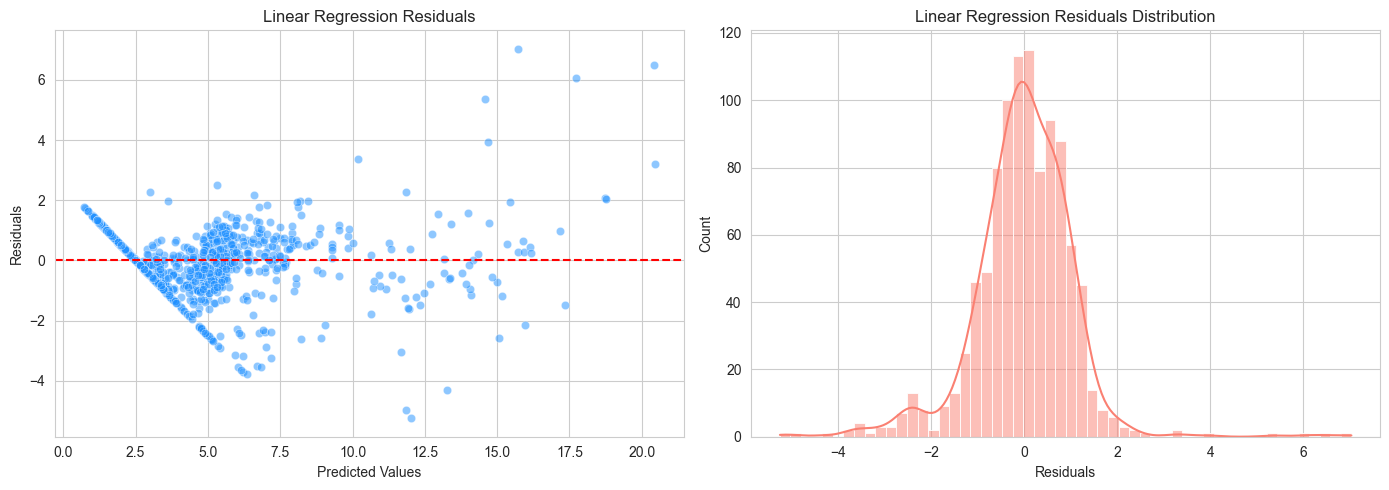

Ridge Regression Performance:
  Train RMSE: 1.0259
  Test RMSE: 1.0583
  Test MAE: 1.1200
  Test R²: 0.8935


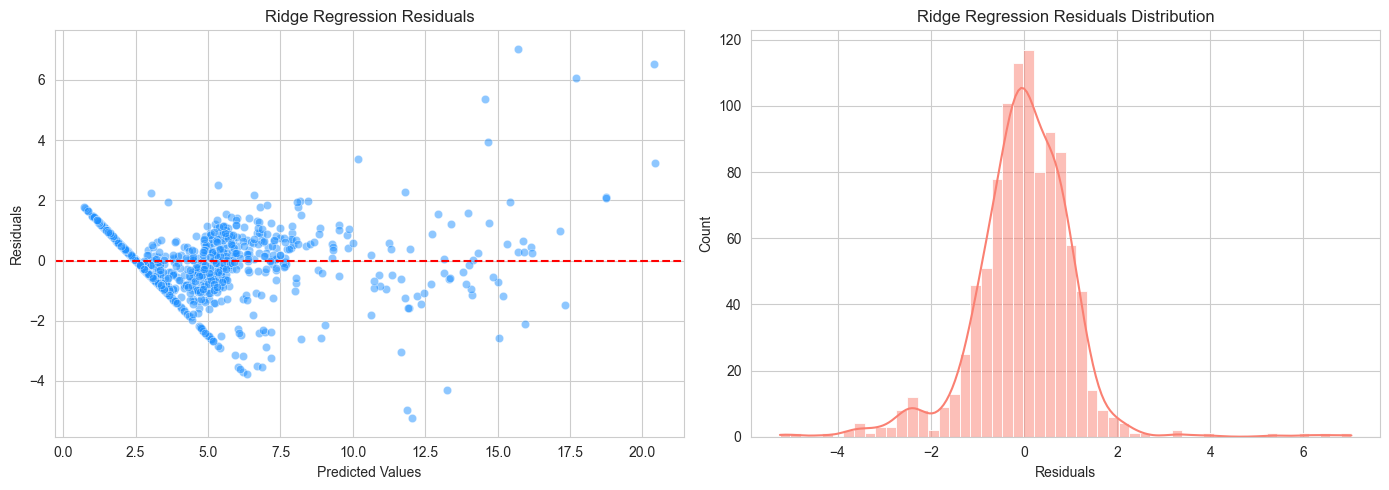

Random Forest Performance:
  Train RMSE: 0.4093
  Test RMSE: 0.9665
  Test MAE: 0.9341
  Test R²: 0.9112


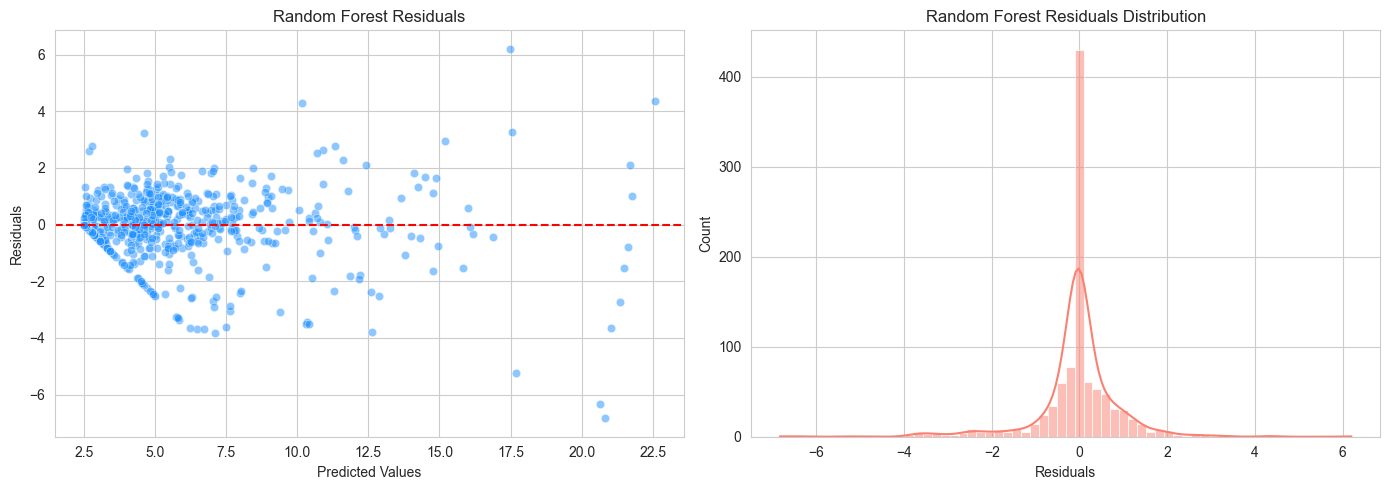

In [43]:
results = []

lr_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
results.append(evaluate_model(lr_pipeline, "Linear Regression", X_train, y_train, X_test, y_test))


ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RidgeCV(alphas=np.logspace(-3, 3, 10)))
])
ridge_pipeline.fit(X_train, y_train)
results.append(evaluate_model(ridge_pipeline, "Ridge Regression", X_train, y_train, X_test, y_test))


rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
])
rf_pipeline.fit(X_train, y_train)
results.append(evaluate_model(rf_pipeline, "Random Forest", X_train, y_train, X_test, y_test))


,Model,RMSE,MAE,R2
0,Random Forest,0.966496,0.934114,0.911169
1,Linear Regression,1.058287,1.119971,0.893495
2,Ridge Regression,1.058315,1.120031,0.893489


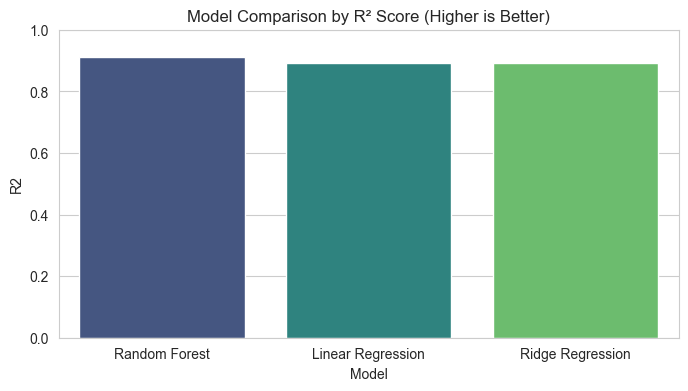

In [44]:
results_df = pd.DataFrame(results).sort_values(by='RMSE').reset_index(drop=True)
display(results_df)

plt.figure(figsize=(8,4))
sns.barplot(data=results_df, x='Model', y='R2', palette='viridis')
plt.title("Model Comparison by R² Score (Higher is Better)")
plt.ylim(0, 1.0)
plt.show()

Top 10 Most Important Features:


,Feature,Importance
0,dti_ratio,0.610626
1,fed_funds_rate,0.215982
2,employment_type_Unemployed,0.057112
3,num_late_payments,0.047371
4,credit_score,0.012910
5,log_annual_income,0.006195
6,annual_income,0.005311
7,employment_years,0.004184
8,loan_to_income_ratio,0.003954
9,existing_debt,0.003230


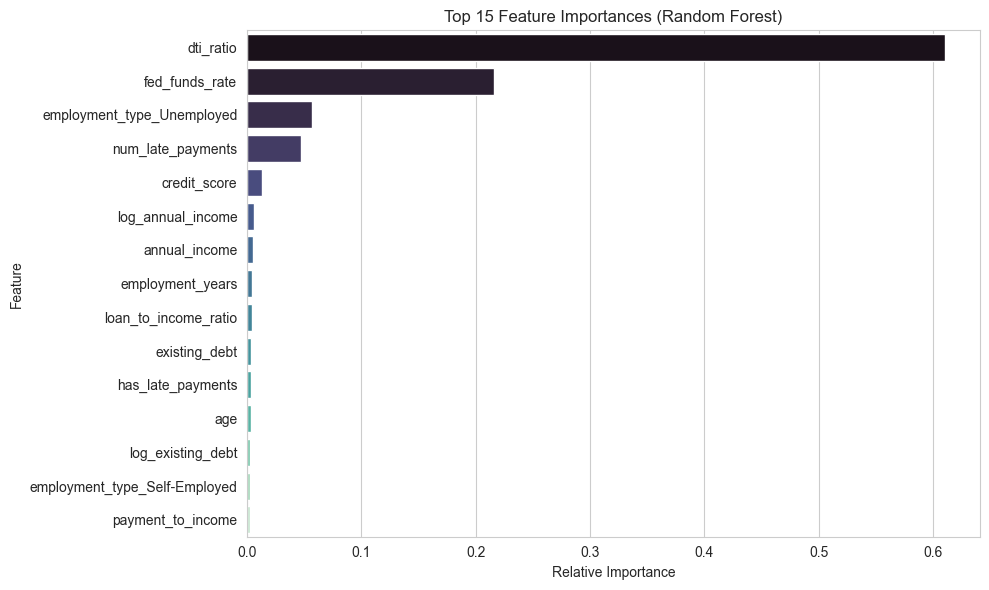

In [45]:

trained_rf = rf_pipeline.named_steps['regressor']
trained_preprocessor = rf_pipeline.named_steps['preprocessor']


num_features = trained_preprocessor.transformers_[0][2]
cat_encoder = trained_preprocessor.named_transformers_['cat']['ohe']
cat_features = list(cat_encoder.get_feature_names_out(trained_preprocessor.transformers_[1][2]))

all_features = num_features + cat_features

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': trained_rf.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index(drop=True)

print("Top 10 Most Important Features:")
display(importance_df.head(10))

# Visualize the Top 15 importances
plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df.head(15), x='Importance', y='Feature', palette='mako')
plt.title('Top 15 Feature Importances (Random Forest)')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../reports/figures/feature_importance.png', dpi=300)
plt.show()

Top 10 Largest Coefficients (Ridge Regression):


,Feature,Coefficient,Magnitude
0,dti_ratio,2.425503,2.425503
1,employment_type_Unemployed,1.753868,1.753868
2,fed_funds_rate,1.431761,1.431761
3,employment_type_Contract,-0.991099,0.991099
4,num_late_payments,0.755988,0.755988
5,employment_type_Self-Employed,-0.523832,0.523832
6,is_stable_employment,-0.483232,0.483232
7,employment_type_Retired,-0.242802,0.242802
8,credit_score,-0.238316,0.238316
9,term_bucket_Short,-0.158802,0.158802


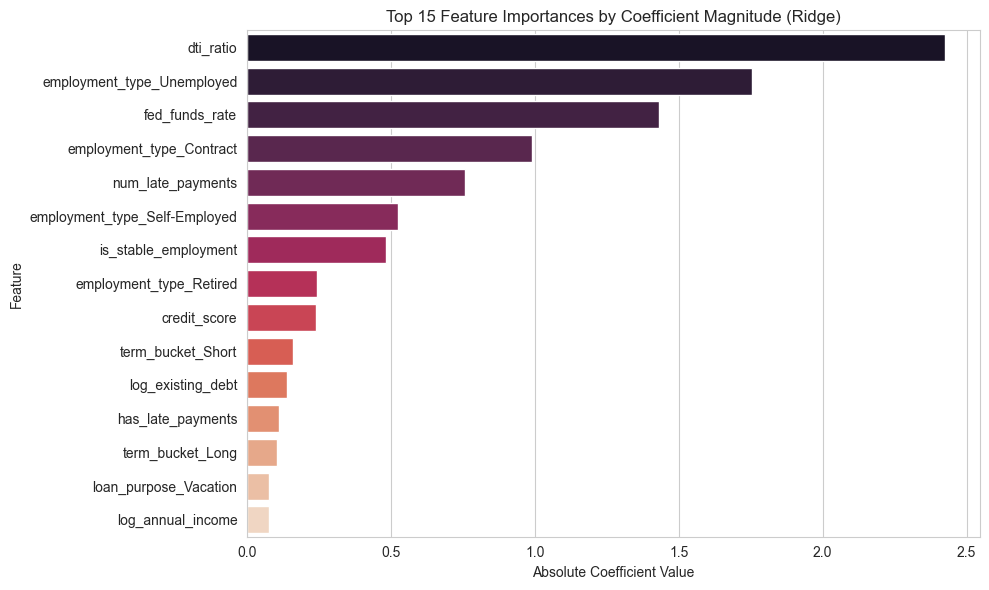

In [46]:
trained_ridge = ridge_pipeline.named_steps['regressor']
trained_preprocessor_ridge = ridge_pipeline.named_steps['preprocessor']

# Combine all feature names (same logic as Random Forest)
num_features = trained_preprocessor_ridge.transformers_[0][2]
cat_encoder = trained_preprocessor_ridge.named_transformers_['cat']['ohe']
cat_features = list(cat_encoder.get_feature_names_out(trained_preprocessor_ridge.transformers_[1][2]))
all_features = num_features + cat_features

# Create a DataFrame of Coefficients
coef_df = pd.DataFrame({
    'Feature': all_features,
    'Coefficient': trained_ridge.coef_,
    'Magnitude': np.abs(trained_ridge.coef_) # Absolute value for sorting importance
}).sort_values(by='Magnitude', ascending=False).reset_index(drop=True)

# Display top 10 most impactful features
print("Top 10 Largest Coefficients (Ridge Regression):")
display(coef_df.head(10))

# Visualize the Top 15 Magnitudes
plt.figure(figsize=(10, 6))
sns.barplot(data=coef_df.head(15), x='Magnitude', y='Feature', palette='rocket')
plt.title('Top 15 Feature Importances by Coefficient Magnitude (Ridge)')
plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [48]:
from sklearn.model_selection import KFold, cross_validate, RandomizedSearchCV
from scipy.stats import randint, uniform
from joblib import dump
import os


cv = KFold(n_splits=5, shuffle=True, random_state=42)

ridge_cv_pipe = Pipeline([
    ("preprocessor", build_sklearn_pipeline(X_train)),
    ("regressor", RidgeCV(alphas=np.logspace(-3, 3, 10)))
])

rf_cv_pipe = Pipeline([
    ("preprocessor", build_sklearn_pipeline(X_train)),
    ("regressor", RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1))
])

scoring = {
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error",
    "r2": "r2"
}

ridge_cv_scores = cross_validate(ridge_cv_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
rf_cv_scores = cross_validate(rf_cv_pipe, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)

cv_results = pd.DataFrame([
    {
        "Model": "RidgeCV",
        "CV_RMSE_Mean": -ridge_cv_scores["test_rmse"].mean(),
        "CV_RMSE_Std": ridge_cv_scores["test_rmse"].std(),
        "CV_MAE_Mean": -ridge_cv_scores["test_mae"].mean(),
        "CV_R2_Mean": ridge_cv_scores["test_r2"].mean(),
    },
    {
        "Model": "RandomForest (base)",
        "CV_RMSE_Mean": -rf_cv_scores["test_rmse"].mean(),
        "CV_RMSE_Std": rf_cv_scores["test_rmse"].std(),
        "CV_MAE_Mean": -rf_cv_scores["test_mae"].mean(),
        "CV_R2_Mean": rf_cv_scores["test_r2"].mean(),
    }
]).sort_values("CV_RMSE_Mean")

display(cv_results)

,Model,CV_RMSE_Mean,CV_RMSE_Std,CV_MAE_Mean,CV_R2_Mean
1,RandomForest (base),0.876611,0.060424,0.506859,0.923049
0,RidgeCV,1.034307,0.080615,0.735026,0.892671


In [49]:
rf_tune_pipe = Pipeline([
    ("preprocessor", build_sklearn_pipeline(X_train)),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=-1))
])

param_dist = {
    "regressor__n_estimators": randint(200, 900),
    "regressor__max_depth": randint(6, 24),
    "regressor__min_samples_split": randint(2, 20),
    "regressor__min_samples_leaf": randint(1, 10),
    "regressor__max_features": uniform(0.4, 0.6)  # samples float in [0.4, 1.0)
}

rf_search = RandomizedSearchCV(
    estimator=rf_tune_pipe,
    param_distributions=param_dist,
    n_iter=35,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

rf_search.fit(X_train, y_train)

print("Best CV RMSE:", -rf_search.best_score_)
print("Best Params:", rf_search.best_params_)
best_rf_pipeline = rf_search.best_estimator_

Fitting 5 folds for each of 35 candidates, totalling 175 fits
Best CV RMSE: 0.8595187401426694
Best Params: {'regressor__max_depth': 22, 'regressor__max_features': np.float64(0.82680517164919), 'regressor__min_samples_leaf': 3, 'regressor__min_samples_split': 2, 'regressor__n_estimators': 578}


In [50]:
y_pred_best = best_rf_pipeline.predict(X_test)

best_rmse = np.sqrt(mean_squared_error(y_test, y_pred_best))
best_mae = mean_absolute_error(y_test, y_pred_best)
best_r2 = r2_score(y_test, y_pred_best)

print("Tuned Random Forest Test Metrics")
print(f"RMSE: {best_rmse:.4f}")
print(f"MAE : {best_mae:.4f}")
print(f"R2  : {best_r2:.4f}")

Tuned Random Forest Test Metrics
RMSE: 0.9598
MAE : 0.5148
R2  : 0.9124


In [52]:

error_df = X_test.copy()
error_df["actual"] = y_test.values
error_df["pred"] = y_pred_best
error_df["abs_error"] = np.abs(error_df["actual"] - error_df["pred"])

# If categories are available in X_test, this gives group-level error insight
group_cols = [c for c in ["employment_type", "loan_purpose", "origination_quarter"] if c in error_df.columns]
for col in group_cols:
    print(f"\nMean absolute error by {col}:")
    display(
        error_df.groupby(col)["abs_error"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=False)
        .head(10)
    )

# Numeric slice analysis
numeric_probe_cols = [c for c in ["dti_ratio", "loan_to_income_ratio", "credit_score"] if c in error_df.columns]
for col in numeric_probe_cols:
    error_df[f"{col}_bin"] = pd.qcut(error_df[col], q=5, duplicates="drop")
    print(f"\nMean absolute error across {col} quintiles:")
    display(
        error_df.groupby(f"{col}_bin")["abs_error"]
        .agg(["mean", "median", "count"])
        .sort_values("mean", ascending=False)
    )


Mean absolute error by employment_type:


,mean,median,count
employment_type,,,
Unemployed,1.112205,0.698034,69
Contract,0.538086,0.173395,139
Self-Employed,0.501705,0.274149,208
Salaried,0.448106,0.110474,539
Retired,0.385473,0.261497,45



Mean absolute error by loan_purpose:


,mean,median,count
loan_purpose,,,
Debt Consolidation,0.560934,0.222917,259
Vacation,0.557626,0.315339,39
Medical,0.527079,0.198069,87
Business,0.515466,0.201302,140
Home Improvement,0.506200,0.203432,181
Auto,0.484909,0.201910,194
Education,0.440212,0.123780,100



Mean absolute error by origination_quarter:


...

,mean,median,count
dti_ratio_bin,,,
"(0.306, 3.0]",1.079184,0.649029,200
"(0.127, 0.306]",0.471012,0.183166,200
"(0.067, 0.127]",0.382791,0.094101,199
"(0.031, 0.067]",0.328837,0.062949,201
"(0.0009, 0.031]",0.312276,0.069739,200



Mean absolute error across loan_to_income_ratio quintiles:


,mean,median,count
loan_to_income_ratio_bin,,,
"(1.832, 23.264]",0.737176,0.410054,200
"(0.983, 1.832]",0.525672,0.151755,200
"(0.619, 0.983]",0.470172,0.142267,200
"(0.0366, 0.361]",0.458575,0.121444,200
"(0.361, 0.619]",0.382237,0.180382,200



Mean absolute error across credit_score quintiles:


,mean,median,count
credit_score_bin,,,
"(311.0, 337.0]",0.718506,0.362510,203
"(337.0, 361.0]",0.573807,0.146674,198
"(299.999, 311.0]",0.451206,0.262142,203
"(385.0, 506.0]",0.428295,0.181136,193
"(361.0, 385.0]",0.399211,0.122550,203


In [53]:
os.makedirs("../models", exist_ok=True)
os.makedirs("../reports", exist_ok=True)

# Save best model pipeline
dump(best_rf_pipeline, "../models/best_random_forest_pipeline.joblib")

# Save metric summary
final_metrics = pd.DataFrame([{
    "model": "Tuned Random Forest",
    "rmse_test": best_rmse,
    "mae_test": best_mae,
    "r2_test": best_r2,
    "cv_rmse_best": -rf_search.best_score_
}])
final_metrics.to_csv("../reports/final_model_metrics.csv", index=False)

# Save prediction errors (test set)
error_df.to_csv("../reports/test_error_analysis.csv", index=False)

print("Saved:")
print("- ../models/best_random_forest_pipeline.joblib")
print("- ../reports/final_model_metrics.csv")
print("- ../reports/test_error_analysis.csv")

Saved:
- ../models/best_random_forest_pipeline.joblib
- ../reports/final_model_metrics.csv
- ../reports/test_error_analysis.csv
